In [208]:
import optuna
from collections.abc import Callable
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.ERROR)


SAVE_FILENAME = 'results.csv'

In [209]:
def pol(odd_coefs):
    def f(x: float):
        ans = 0
        summer = x
        x_sqr = x*x
        for coef in odd_coefs:
            ans += coef * summer
            summer *= x_sqr
        return ans
    return f

In [210]:
def repeat_func(f: Callable, times: int) -> Callable:
    if times == 0:
        return lambda x: x
    elif times == 1:
        return f
    elif times % 2 == 0:
        ans = repeat_func(f, times // 2)
        return lambda x: ans(ans(x))
    else:
        ans = repeat_func(f, times // 2)
        return lambda x: ans(ans(f(x)))

In [211]:
def sign_l2_loss(f: Callable, interval=[0,1], h=1e-5):
    if isinstance(interval, int | float):
        interval = [0, interval]
    if len(interval) == 1:
        interval = [0, interval[0]]
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right    
    n_steps = int((right - left) / h)
    assert n_steps != 0, "Слишком маленький интервал по сравнению с шагом"
    try:
        x = left
        ans = h * f(x) ** 2
        for _ in range(1, n_steps):
            x += h
            ans += h * (f(x)-1) ** 2
        return ans ** 0.5
    except OverflowError:
        return float('+inf')

In [212]:
def sign_max_loss(f: Callable, interval=[0,1], h=1e-5):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right    
    n_steps = int((right - left) / h)
    assert n_steps != 0, "Слишком маленький интервал по сравнению с шагом"
    try:
        x = left
        ans = abs(f(x))
        for i in range(1, n_steps):
            x += h
            ans = max(ans, abs(f(x)-1))
        return ans
    except OverflowError:
        return float('+inf')

In [213]:
def NewtonS(odd_coefs: list, n: int):
    f = pol(odd_coefs)
    f = repeat_func(f, n)
    return f


In [214]:
def abstruct_objective(coef_len: int, max_x: float, n: int, metric='l2'):
    def objective(trial: optuna.Trial):
        odd_coefs = []
        for i in range(coef_len):
            odd_coefs.append(
                trial.suggest_float(f"a{i}", -10, 10)
            )
        f = NewtonS(odd_coefs, n)
        loss = float('nan')
        if metric == 'l2':
            loss = sign_l2_loss(f, [0, max_x], max_x / 1e4)
        elif metric == 'max':
            loss = sign_max_loss(f, [0, max_x], max_x / 1e4)
        if math.isnan(loss):
            return float('+inf')
        return loss
    return objective

In [215]:
def experiment(coef_len: int, max_x: float, n: int, metric='l2', n_trials=1000):
    filename = f"sqlite:///optuna/sampler_{coef_len}_{int(max_x)}_{n}_{metric}.db"
    sampler = optuna.samplers.CmaEsSampler()
    study = optuna.create_study(
        sampler=sampler,
        storage=filename,
        study_name=f"Study({coef_len},{int(max_x)},{n},{metric})",
        direction='minimize',
        load_if_exists=True,
    )
    study.optimize(
        abstruct_objective(
            coef_len, max_x, n,
            metric=metric
        ), n_trials=n_trials,
        show_progress_bar=True
    )
    try:
        best_value = study.best_value
        best_params = study.best_params
    except ValueError:
        best_value = max_x
        best_params = {}

    return (coef_len, max_x, n, best_value, best_params)


In [216]:
results = []
breake = 2
for coef_len in [3, 5, 7]:
    odd_coef_len = coef_len // 2 + 1
    for max_x in [1, 5, 10, 20]:
        for n in [5, 8]:
            if breake > 0:
                breake -= 1
                continue
            results.append(
                experiment(odd_coef_len, max_x, n, 'l2', n_trials=2000)
            )

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [217]:
def get_df(results: list[tuple[int, int, int, float, dict[str, float]]]):
    coef_counts, max_xs, NSs, losses, ds = zip(*results)
    d_a1 = [d.get('a0', 0) for d in ds]
    d_a3 = [d.get('a1', 0) for d in ds]
    d_a5 = [d.get('a2', 0) for d in ds]
    d_a7 = [d.get('a3', 0) for d in ds]
    df = pd.DataFrame({
        "loss": losses,
        "coef_count": coef_counts,
        "max_x": max_xs,
        "NS_n": NSs,
        "a1": d_a1,
        "a3": d_a3,
        "a5": d_a5,
        "a7": d_a7,
    })
    return df

In [218]:
df = get_df(results)
df

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,1.189791e-01,2,1,5,1.962775,-0.974549,0.000000,0.000000
1,4.764048e-02,2,1,8,-1.912149,0.908837,0.000000,0.000000
2,7.156112e-01,2,5,5,0.961547,-0.032120,0.000000,0.000000
3,1.017991e+00,2,5,8,-1.055222,0.033140,0.000000,0.000000
4,1.089911e+00,2,10,5,0.808050,-0.006530,0.000000,0.000000
5,1.136139e+00,2,10,8,0.904885,-0.006992,0.000000,0.000000
6,7.931789e+19,2,20,5,-0.031789,0.003672,0.000000,0.000000
7,inf,2,20,8,0.645468,-1.918105,0.000000,0.000000
8,3.979227e-02,3,1,5,3.100870,-3.423672,1.318382,0.000000
9,4.572702e-03,3,1,8,3.079511,-3.386635,1.306934,0.000000


In [219]:
import os


sorted_colnames = ['coef_count', 'max_x', 'NS_n']

if os.path.exists(SAVE_FILENAME):
    # Загружаем существующий файл
    old_df = pd.read_csv(SAVE_FILENAME, index_col=False)
    # Убедимся, что индекс уникален и состоит из ключевых столбцов
    old_df = old_df.drop_duplicates(subset=sorted_colnames, keep='first')  # на случай дубликатов

    # Объединяем старые и новые данные по ключу
    df = df.drop_duplicates(subset=sorted_colnames, keep='first')

    # Объединяем с помощью merge, чтобы сравнить loss
    merged = pd.merge(
        old_df,
        df,
        on=sorted_colnames,
        how='outer',
        suffixes=('_old', '_new'),
        indicator=True
    )

    # Случай 1: только в новых данных → добавить
    only_new = merged[merged['_merge'] == 'right_only'].copy()
    only_new = only_new.rename(columns={col + '_new': col for col in df.columns if col not in sorted_colnames})
    only_new = only_new[df.columns]  # сохраняем порядок столбцов

    # Случай 2: только в старых → оставить
    only_old = merged[merged['_merge'] == 'left_only'].copy()
    only_old = only_old.rename(columns={col + '_old': col for col in old_df.columns if col not in sorted_colnames})
    only_old = only_old[old_df.columns]

    # Случай 3: есть и там, и там → выбрать с меньшим loss
    both = merged[merged['_merge'] == 'both'].copy()
    # Заменяем inf на np.inf, если ещё не так
    loss_old = pd.to_numeric(both['loss_old'], errors='coerce').fillna(np.inf)
    loss_new = pd.to_numeric(both['loss_new'], errors='coerce').fillna(np.inf)

    # Выбираем строки, где loss_new лучше (меньше или равен, но обычно — меньше)
    better_new = loss_new < loss_old  # inf < inf → False, inf < 5 → False, 3 < inf → True — всё верно

    # Формируем обновлённые строки
    updated_rows = both.copy()
    for col in df.columns:
        if col in sorted_colnames:
            continue
        # Берём значение из новой строки, если она лучше; иначе — из старой
        updated_rows[col] = np.where(better_new, both[col + '_new'], both[col + '_old'])

    # Убираем суффиксы и лишние столбцы
    final_both = updated_rows[old_df.columns]

    # Собираем финальный DataFrame
    final_df = pd.concat([only_old, only_new, final_both], ignore_index=True)

    # Сохраняем
    os.remove(SAVE_FILENAME)
    final_df.to_csv(SAVE_FILENAME, index=False)
    df = final_df

    # Определяем статус
    if len(only_new) > 0 or better_new.any():
        print("GOOD UPDATE")
    else:
        print("BAD UPDATE")

else:
    # Файл не существует — просто сохраняем
    df.to_csv(SAVE_FILENAME, index=False)
    print("SAVE")

GOOD UPDATE


In [220]:
df = pd.read_csv(SAVE_FILENAME, index_col=False)
df

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,0.118979,2,1,5,1.962775,-0.974549,0.000000,0.000000
1,0.047640,2,1,8,-1.912149,0.908837,0.000000,0.000000
2,0.715611,2,5,5,0.961547,-0.032120,0.000000,0.000000
3,1.017991,2,5,8,-1.055222,0.033140,0.000000,0.000000
4,1.089911,2,10,5,0.808050,-0.006530,0.000000,0.000000
5,1.136139,2,10,8,0.904885,-0.006992,0.000000,0.000000
6,4.471077,2,20,5,0.196162,-0.000922,0.000000,0.000000
7,inf,2,20,8,-1.882495,3.532314,0.000000,0.000000
8,0.039792,3,1,5,3.100870,-3.423672,1.318382,0.000000
9,0.004573,3,1,8,3.079511,-3.386635,1.306934,0.000000


In [221]:
def plots(df: pd.DataFrame, max_x = 1, alpha=0.5):
    max_x_per_cent = 100 * max_x
    for n_row, row in df[df['max_x'] == max_x].iterrows():
        f = NewtonS([row[f'a{i}']for i in range(1, 8, 2)], int(row['NS_n']))
        x_es = [i/100 for i in range(max_x_per_cent)]
        y_es = [f(i/100) for i in range(max_x_per_cent)]
        if max(*y_es) > 10 or min(*y_es) < -10:
            continue
        plt.plot(x_es, y_es, label=n_row, alpha=alpha)
    plt.legend()
    plt.show()

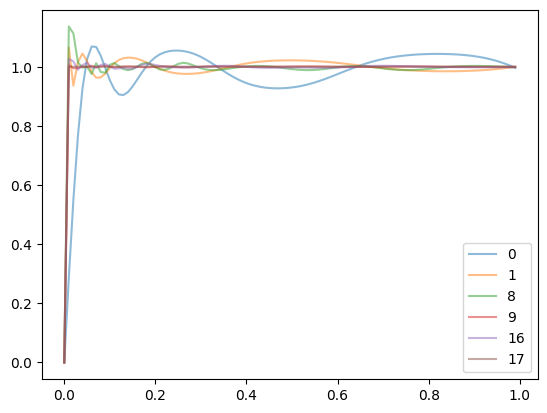

In [222]:
plots(df)

C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x


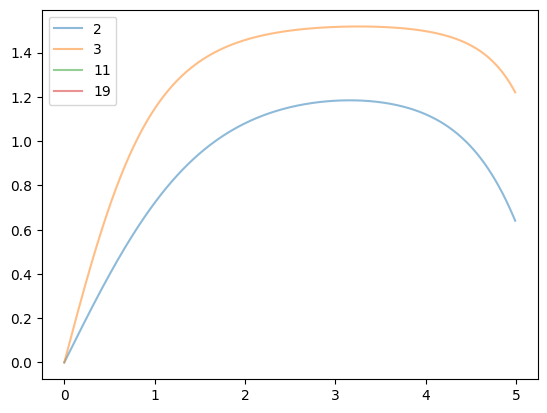

In [223]:
plots(df, max_x=5)

In [224]:
def plot_from_func(f: Callable, max_x: float, n_points: int = 100):
    x_es = [i/n_points for i in range(int(max_x * n_points))]
    y_es = np.array([f(i/n_points) for i in range(int(max_x * n_points))])
    plt.plot(x_es, y_es)
    return y_es

In [225]:
def plots_minimum(df: pd.DataFrame, n_points: int = 100):
    min_loss = df[df['loss'] != 0.0]['loss'].min()
    row: pd.DataFrame = df[df['loss'] == min_loss]
    max_x = row['max_x'].iloc[0]
    coefs = [row[f'a{i}'].iloc[0] for i in range(1, 8, 2)]
    f = NewtonS(coefs, int(row['NS_n'].iloc[0]))
    y_es = plot_from_func(f, max_x, n_points)
    plt.title(f'loss={(((y_es[1:] - 1)**2).sum() + y_es[0]**2) / n_points * max_x}')
    plt.show()
    return f, row

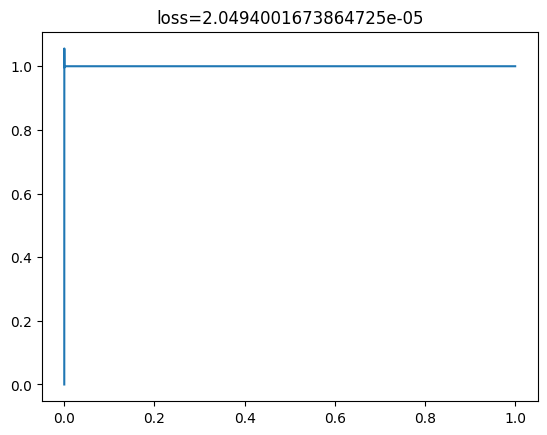

In [226]:
f, row = plots_minimum(df, int(1e5))

In [227]:
row

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
17,0.000073,4,1,8,3.306573,-6.177358,5.884066,-2.013279


In [228]:
coefs = [-3.0641098556945208, 3.2644138887880576, -1.2067686767868482]

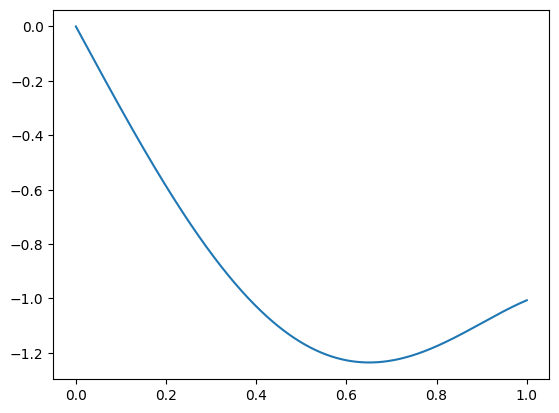

In [229]:
init_f = pol(coefs)
plot_from_func(init_f, 1, int(1e5))
plt.show()

C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x


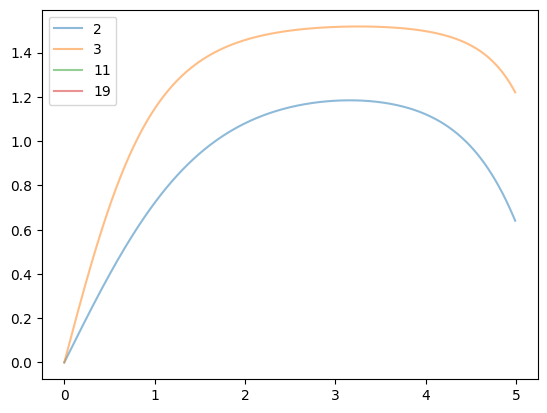

In [230]:
plots(df, max_x = 5)

C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer


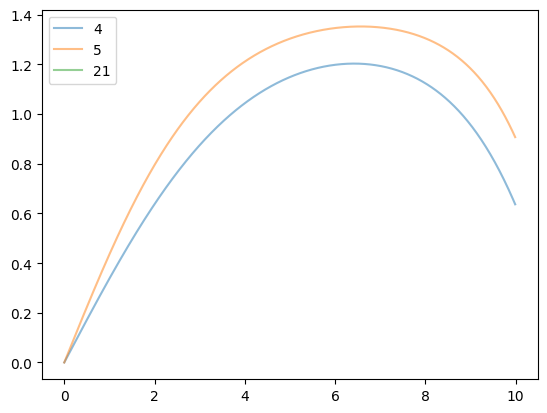

In [231]:
plots(df, max_x = 10)

C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: overflow encountered in scalar multiply
  ans += coef * summer
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sqr = x*x
C:\Users\Ali\AppData\Local\Temp\ipykernel_31512\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer


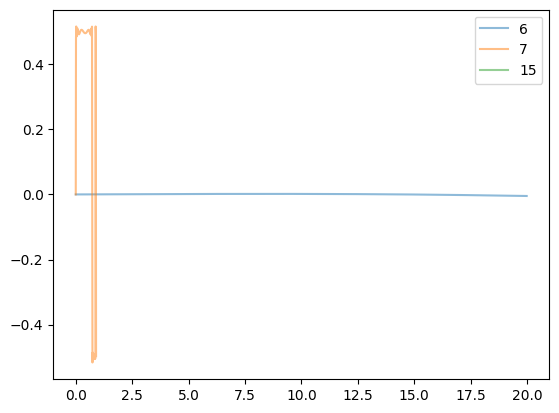

In [232]:
plots(df, max_x = 20)

In [233]:
assert False

AssertionError: 

In [ ]:
results_l2 = []
for coef_len in [3, 5, 7]:
    odd_coef_len = coef_len // 2 + 1
    for max_x in [1, 5, 10, 20]:
        for n in [5, 8]:
            results_l2.append(
                experiment(odd_coef_len, max_x, n, 'max')
            )

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df_2 = get_df(results_l2)
df_2

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,9.882706e-01,2,1,5,2.593320,-0.784668,0.000000,0.000000
1,8.387037e-01,2,1,8,2.518545,-1.858919,0.000000,0.000000
2,9.999845e-01,2,5,5,0.498947,-0.008898,0.000000,0.000000
3,9.999118e-01,2,5,8,-0.805021,0.022702,0.000000,0.000000
4,2.711947e+00,2,10,5,1.074818,-0.007607,0.000000,0.000000
5,4.989921e+165,2,10,8,-1.764289,0.027930,0.000000,0.000000
6,1.964169e+01,2,20,5,1.618520,-0.001474,0.000000,0.000000
7,inf,2,20,8,-4.118435,2.785468,0.000000,0.000000
8,8.822029e-01,3,1,5,4.114544,-5.143178,1.653439,0.000000
9,1.878935e-01,3,1,8,-3.140329,4.224922,-1.896752,0.000000


C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:8: RuntimeWarning: overflow encountered in scalar multiply
  summer *= x_sqr
C:\Users\Ali\AppData\Local\Temp\ipykernel_47928\658514837.py:7: RuntimeWarning: invalid value encountered in scalar add
  ans += coef * summer


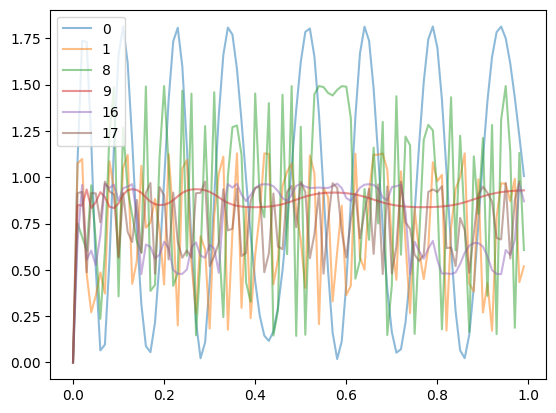

In [ ]:
plots(df_2)

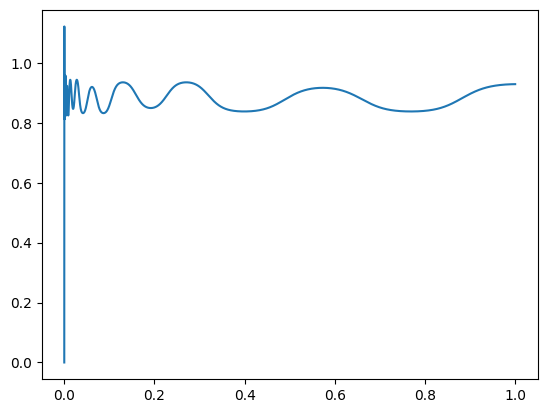

In [ ]:
f = plots_minimum(df_2, 100000)

In [ ]:
f(0), f(1e-1), f(1e-2), f(1e-3), f(1e-4), f(1e-5), f(1e-6), f(1e-7), f(1e-8), f(1e-9), f(1e-10), f(1e-11),  f(1e-12),

(0.0,
 0.8581186751595637,
 0.8495017063626313,
 0.8399291551441883,
 0.8265090396944488,
 0.09445205099785263,
 0.009457912015169764,
 0.0009458039178990023,
 9.458040450637697e-05,
 9.458040463354179e-06,
 9.458040463481342e-07,
 9.458040463482611e-08,
 9.458040463482625e-09)

In [ ]:
f(1e-100)

9.458040463482626e-97

In [ ]:
f(0.5)

0.8873047066034535